In [3]:
import imageio.v2 as imageio
import numpy as np
image_names = [f"{i}.jpeg" if i != 8 else "8.jpg" for i in range(1, 9)]
images = [imageio.imread(image_names[i]) for i in range(0, 8)]

left_halves = [img[:, :img.shape[1]//2] for img in images]
right_halves = [img[:, img.shape[1]//2:] for img in images]


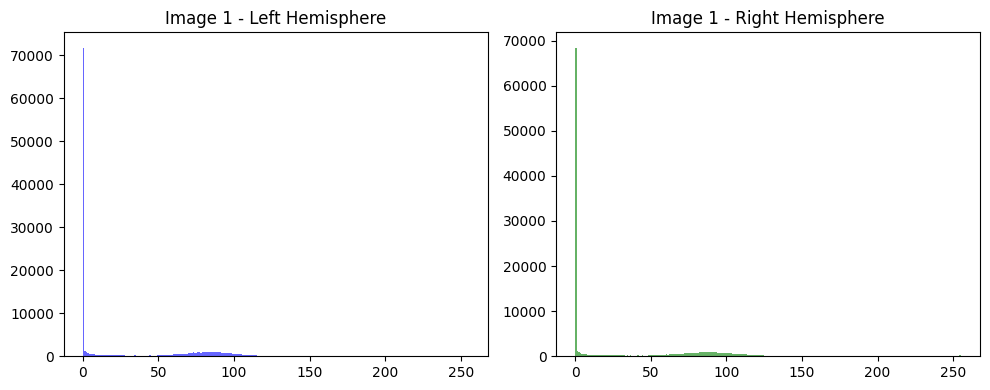

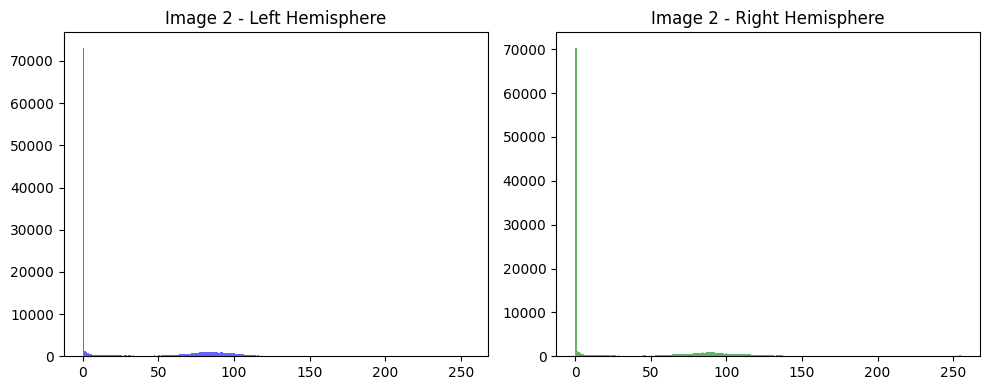

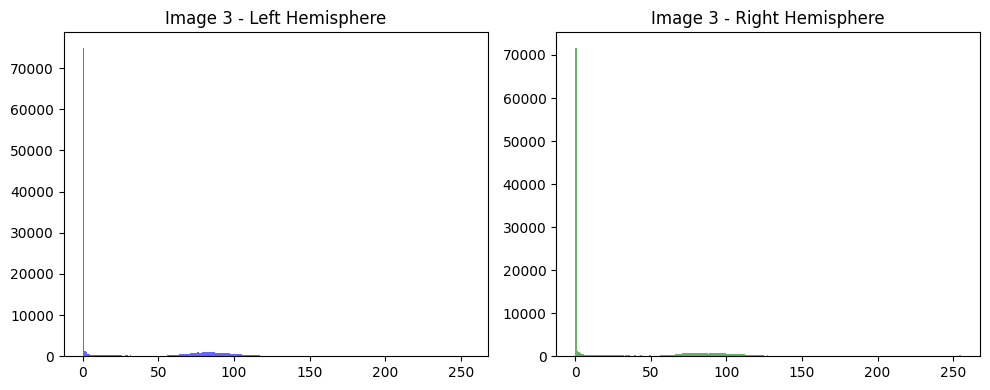

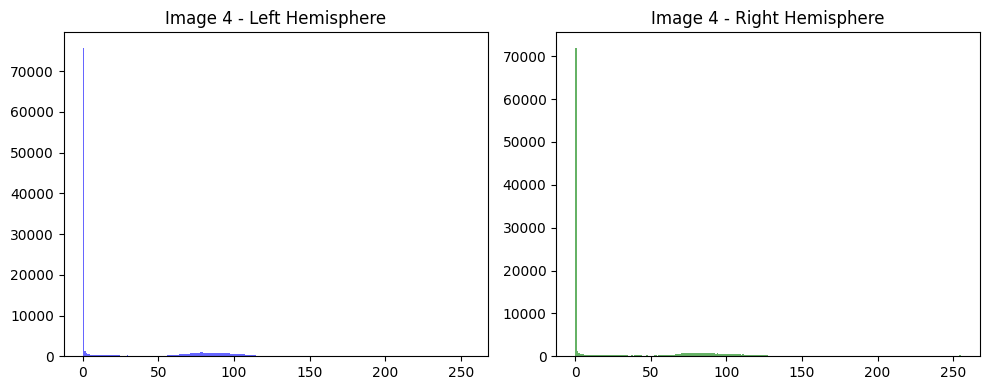

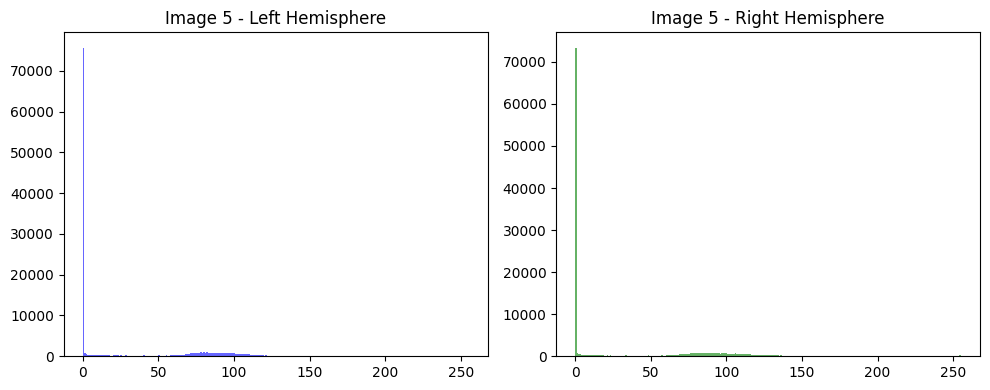

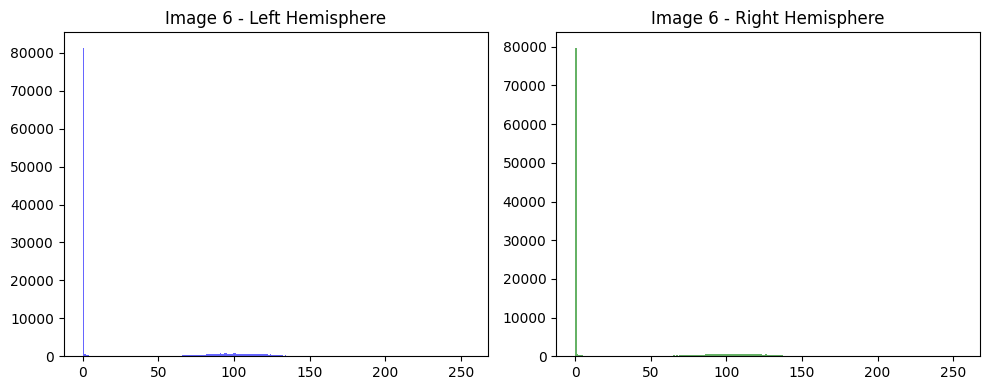

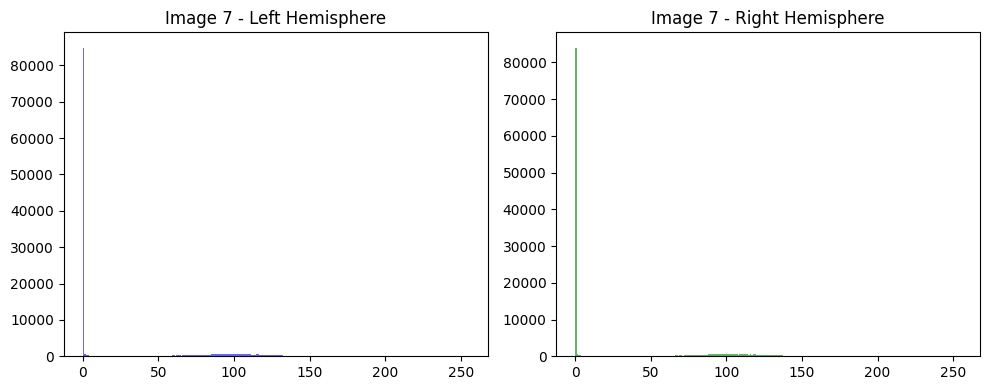

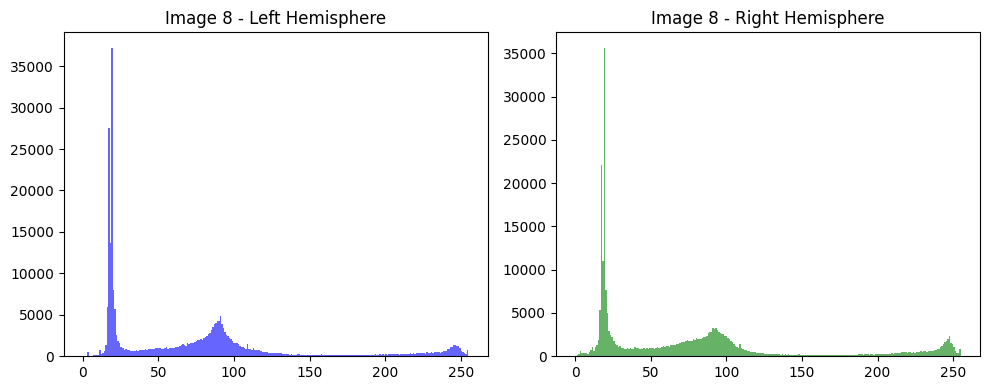

In [4]:
import matplotlib.pyplot as plt

for i in range(8):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(left_halves[i].ravel(), bins=256, color='blue', alpha=0.6)
    plt.title(f'Image {i+1} - Left Hemisphere')

    plt.subplot(1, 2, 2)
    plt.hist(right_halves[i].ravel(), bins=256, color='green', alpha=0.6)
    plt.title(f'Image {i+1} - Right Hemisphere')

    plt.tight_layout()
    plt.show()


<p>در این بخش هیت مپ تفاوت دو نیمکره را رسم می‌کنیم تا یک دید کلی داشته باشیم</p>

In [5]:
def match_histograms(source, template):
    oldshape = source.shape
    source = source.ravel()
    template = template.ravel()

    s_values, bin_idx, s_counts = np.unique(source, return_inverse=True, return_counts=True)
    t_values, t_counts = np.unique(template, return_counts=True)

    s_quantiles = np.cumsum(s_counts).astype(np.float64)
    s_quantiles /= s_quantiles[-1]

    t_quantiles = np.cumsum(t_counts).astype(np.float64)
    t_quantiles /= t_quantiles[-1]

    interp_t_values = np.interp(s_quantiles, t_quantiles, t_values)
    return interp_t_values[bin_idx].reshape(oldshape).astype(np.uint8)


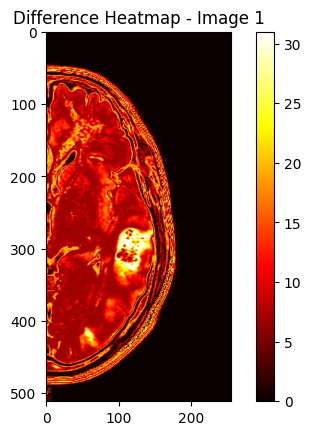

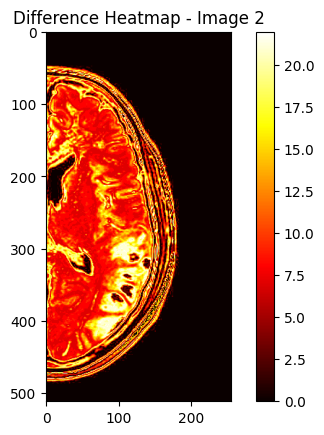

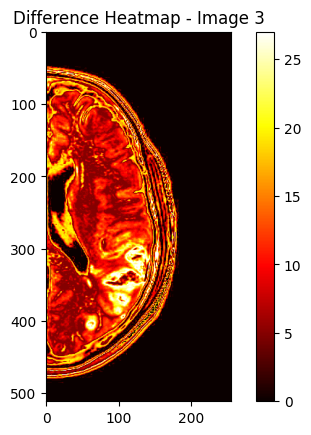

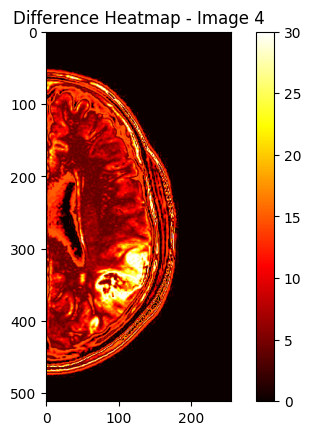

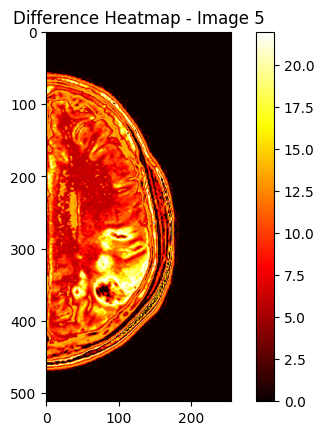

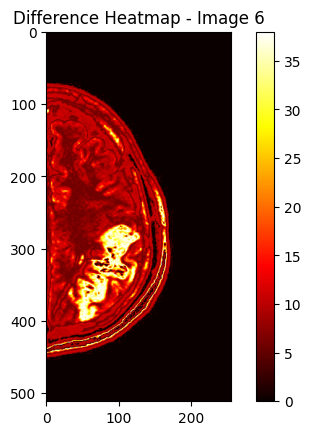

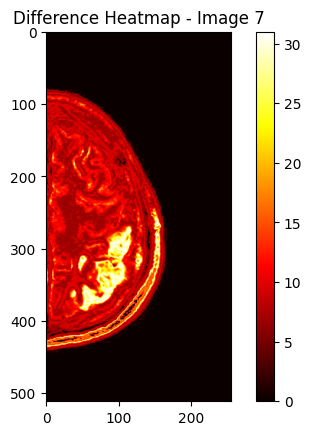

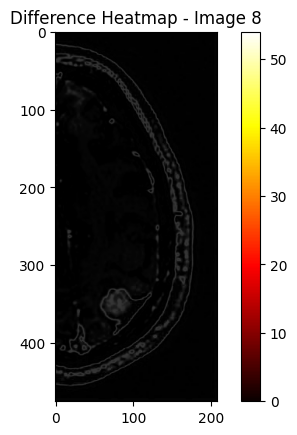

In [6]:
for i in range(8):
    matched = match_histograms(right_halves[i], left_halves[i])
    diff = np.abs(matched.astype(int) - right_halves[i].astype(int))

    plt.imshow(diff, cmap='hot')
    plt.title(f'Difference Heatmap - Image {i+1}')
    plt.colorbar()
    plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio
import scipy.ndimage
import os

<p>در این بخش هیستوگرام دو نیمکره را بررسی می‌کنیم و اگر تفاوت آن ها در یک موضع خاص بیش از 30 پیکسل بود ضایعه مغزی تشخیص می‌دهیم و برای دفاع از ادعایمان هم‌بستگی دو هیستوگرام را هم محاسبه می‌کنیم</p>

Processing 1.jpeg ...


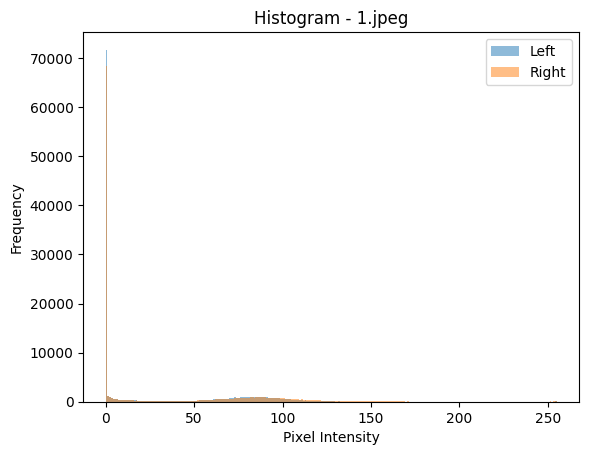

1.jpeg | Histogram correlation: 0.9999
❗ Lesion detected in 1.jpeg


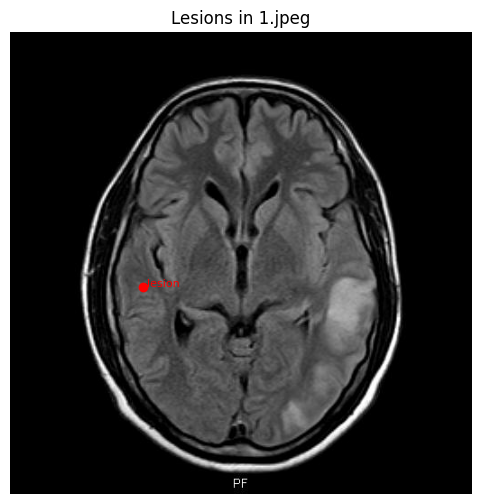

----------------------------------------
Processing 2.jpeg ...


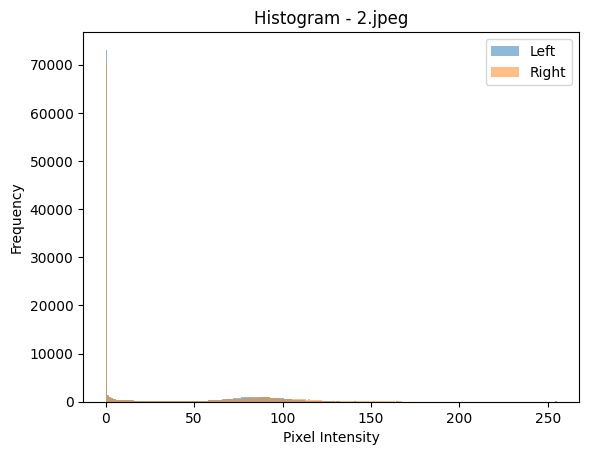

2.jpeg | Histogram correlation: 0.9998
❗ Lesion detected in 2.jpeg


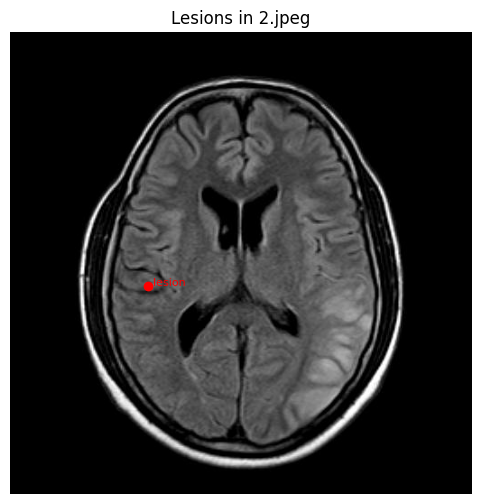

----------------------------------------
Processing 3.jpeg ...


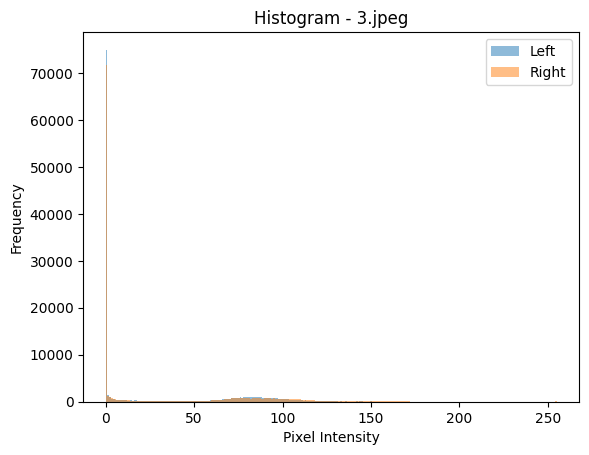

3.jpeg | Histogram correlation: 0.9998
❗ Lesion detected in 3.jpeg


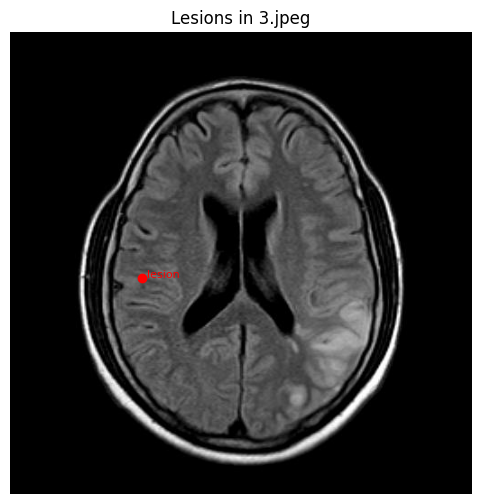

----------------------------------------
Processing 4.jpeg ...


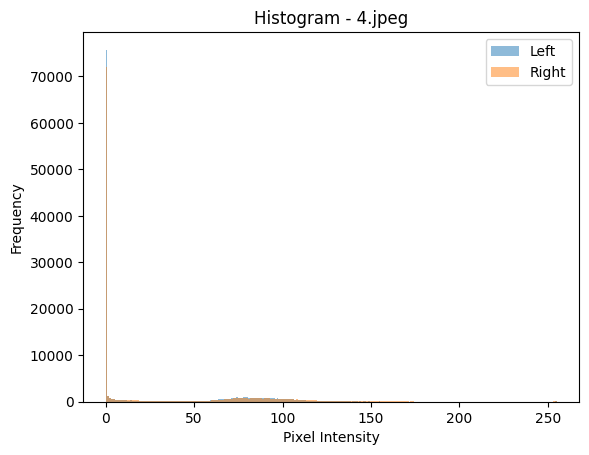

4.jpeg | Histogram correlation: 0.9999
❗ Lesion detected in 4.jpeg


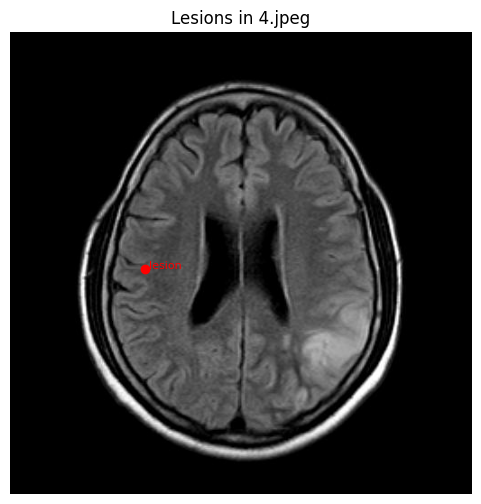

----------------------------------------
Processing 5.jpeg ...


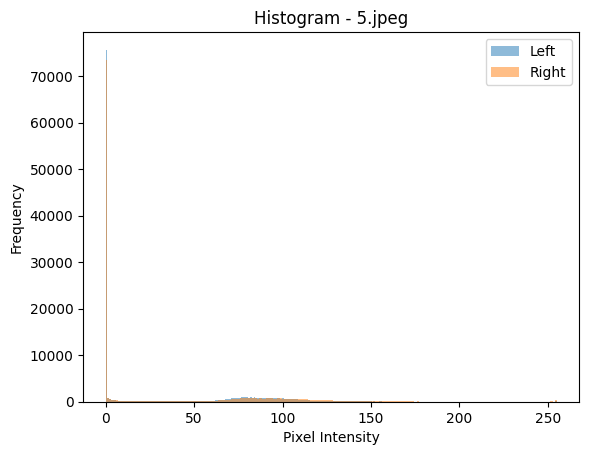

5.jpeg | Histogram correlation: 0.9999
❗ Lesion detected in 5.jpeg


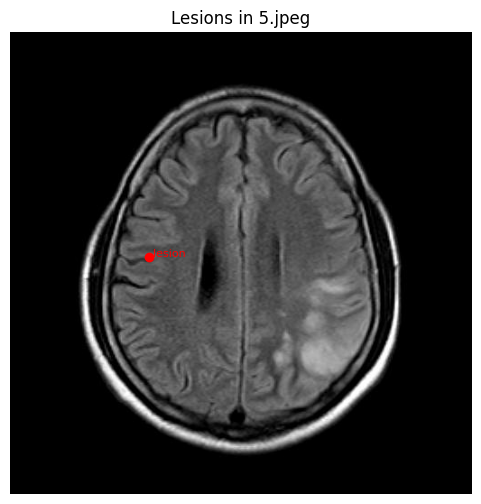

----------------------------------------
Processing 6.jpeg ...


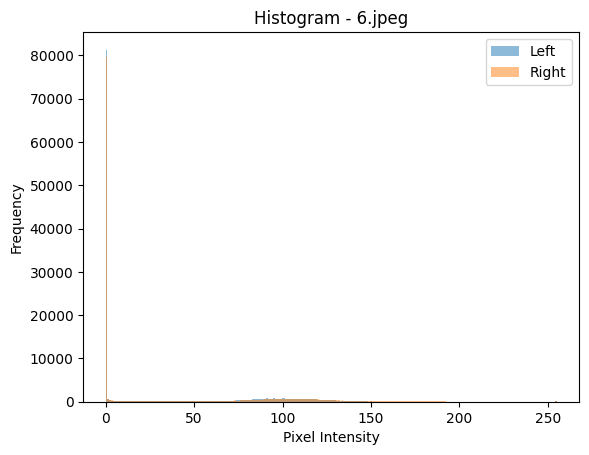

6.jpeg | Histogram correlation: 0.9999
❗ Lesion detected in 6.jpeg


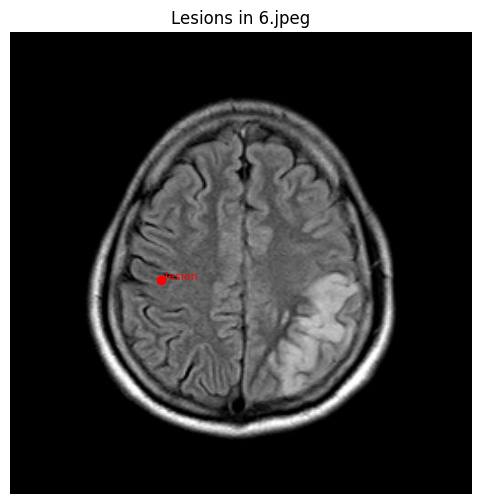

----------------------------------------
Processing 7.jpeg ...


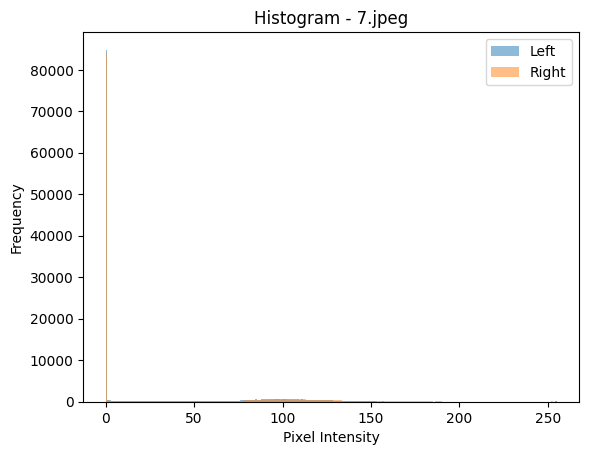

7.jpeg | Histogram correlation: 0.9999
❗ Lesion detected in 7.jpeg


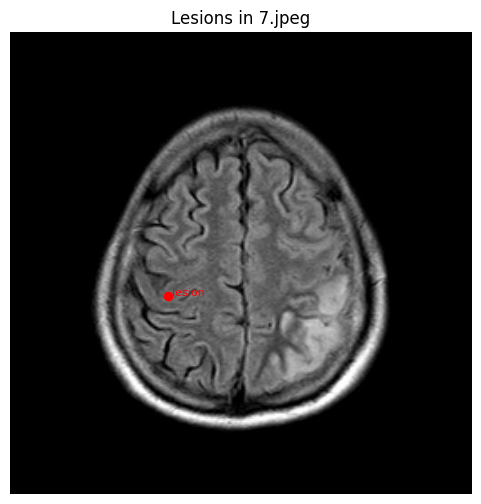

----------------------------------------
Processing 8.jpg ...


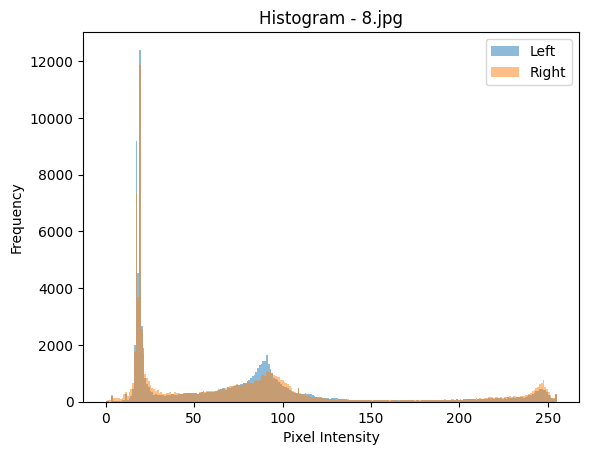

8.jpg | Histogram correlation: 0.9909
❗ Lesion detected in 8.jpg


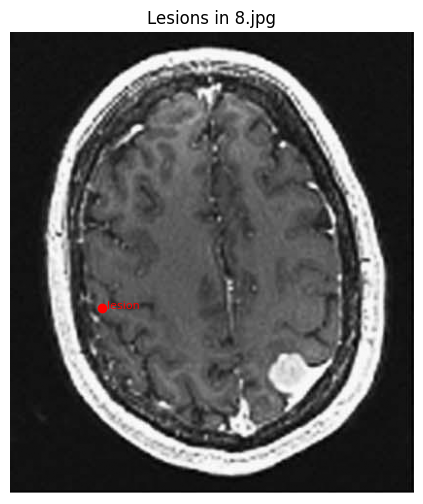

----------------------------------------


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio
import scipy.ndimage
import os

def load_image(path):
    image = iio.imread(path)
    if image.ndim == 3:
        image = np.mean(image, axis=2)
    return image.astype(np.float32)

def split_hemispheres(image):
    mid = image.shape[1] // 2
    left = image[:, :mid]
    right = image[:, mid:]
    right_flipped = np.fliplr(right)
    return left, right_flipped

def plot_histograms(left, right, image_name):
    plt.figure()
    plt.hist(left.ravel(), bins=256, alpha=0.5, label='Left')
    plt.hist(right.ravel(), bins=256, alpha=0.5, label='Right')
    plt.title(f'Histogram - {image_name}')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

def compare_histograms(left, right):
    h1, _ = np.histogram(left, bins=256, range=(0, 255), density=True)
    h2, _ = np.histogram(right, bins=256, range=(0, 255), density=True)
    return np.corrcoef(h1, h2)[0, 1]

def create_lesion_mask(left, right, sigma=2, thresh_mult=1.0):

    diff = np.abs(left - right)

    diff_smoothed = scipy.ndimage.gaussian_filter(diff, sigma=sigma)

    threshold = np.mean(diff_smoothed) + thresh_mult * np.std(diff_smoothed)
    mask = diff_smoothed > threshold

    structure = np.ones((3, 3))
    mask_cleaned = scipy.ndimage.binary_opening(mask, structure=structure)

    return mask_cleaned.astype(np.uint8)

def has_lesion(mask, min_pixels=50):
    return np.sum(mask) >= min_pixels

def get_lesion_regions(lesion_mask, min_size=50):
    structure = np.ones((3, 3), dtype=np.int32)
    labeled, _ = scipy.ndimage.label(lesion_mask, structure=structure)
    sizes = np.bincount(labeled.ravel())

    size_mask = sizes >= min_size
    size_mask[0] = 0
    filtered = size_mask[labeled]

    return filtered

def show_lesions_on_image(image, lesion_mask, title):
    filtered = get_lesion_regions(lesion_mask)
    num_lesions = filtered.max()

    if num_lesions == 0:
        print("No significant lesions detected.")
        plt.figure(figsize=(6, 6))
        plt.imshow(image, cmap='gray')
        plt.title(title + " (No Lesions)")
        plt.axis('off')
        plt.show()
        return

    centroids = scipy.ndimage.center_of_mass(filtered > 0, labels=filtered,
                                              index=np.arange(1, num_lesions + 1))

    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    for y, x in centroids:
        plt.plot(x, y, 'ro')
        plt.text(x + 5, y, 'lesion', color='red', fontsize=8)
    plt.axis('off')
    plt.show()

image_folder = "."
image_names = ["1.jpeg", "2.jpeg", "3.jpeg", "4.jpeg", "5.jpeg", "6.jpeg", "7.jpeg", "8.jpg"]

for name in image_names:
    path = os.path.join(image_folder, name)
    print(f"Processing {name} ...")

    image = load_image(path)
    left, right = split_hemispheres(image)

    plot_histograms(left, right, name)

    corr = compare_histograms(left, right)
    print(f"{name} | Histogram correlation: {corr:.4f}")

    lesion_mask = create_lesion_mask(left, right, sigma=2, thresh_mult=1.0)

    if has_lesion(lesion_mask, min_pixels=50):
        print(f"❗ Lesion detected in {name}")
        show_lesions_on_image(image, lesion_mask, f"Lesions in {name}")
    else:
        print(f"✅ No significant lesion in {name}")
        plt.figure(figsize=(6, 6))
        plt.imshow(image, cmap='gray')
        plt.title(f"{name} (No lesions)")
        plt.axis('off')
        plt.show()

    print("-" * 40)


<p>این بخش هم مثل قبلی است با این تفاوت که یک دایره را به عنوان ضایعه تشخیص می‌دهیم نه یک نقطه خاص را ولی کمی دقت پایینتری نسبت به قبلی دارد</p>


Processing 1.jpeg ...
❗ Lesion detected in 1.jpeg


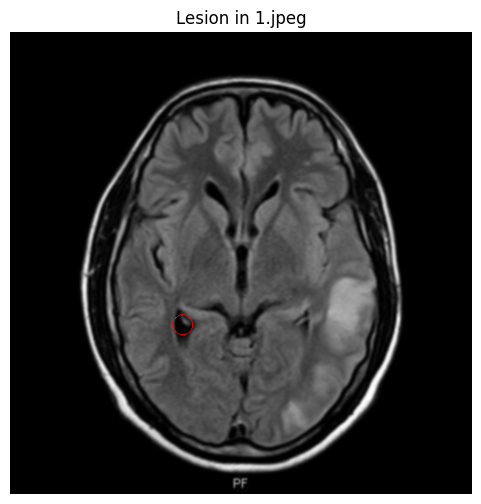


Processing 2.jpeg ...
❗ Lesion detected in 2.jpeg


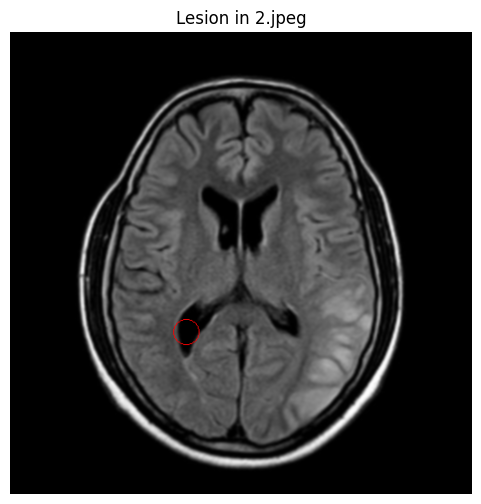


Processing 3.jpeg ...
❗ Lesion detected in 3.jpeg


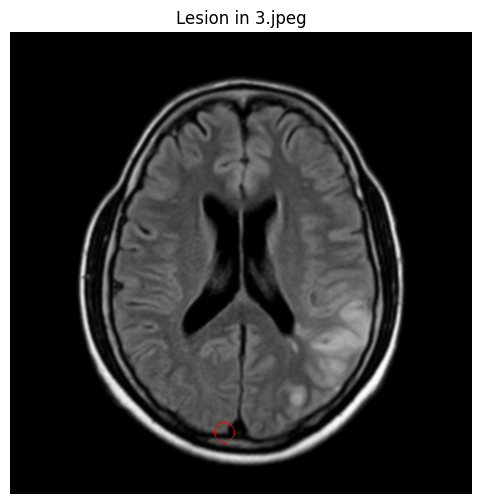


Processing 4.jpeg ...
❗ Lesion detected in 4.jpeg


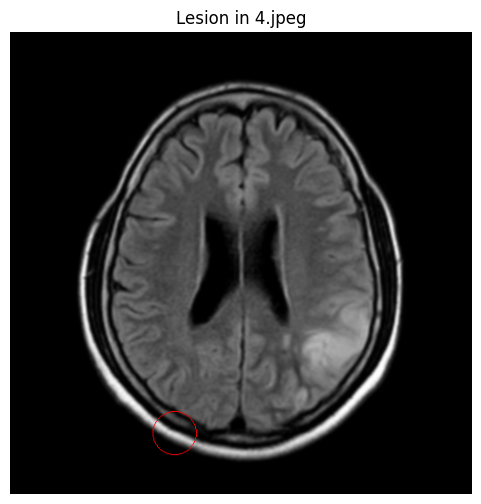


Processing 5.jpeg ...
❗ Lesion detected in 5.jpeg


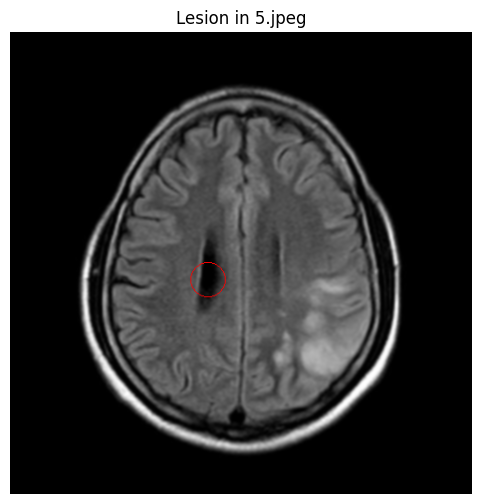


Processing 6.jpeg ...
❗ Lesion detected in 6.jpeg


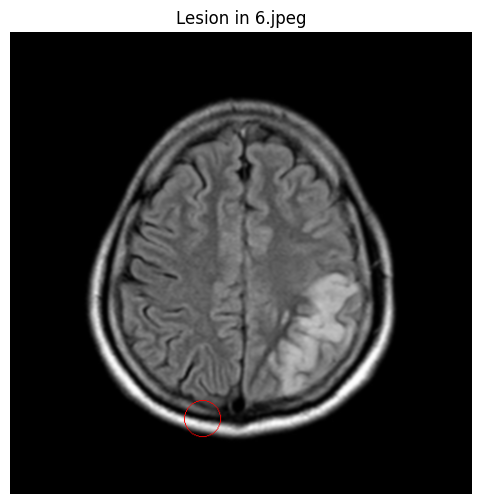


Processing 7.jpeg ...
❗ Lesion detected in 7.jpeg


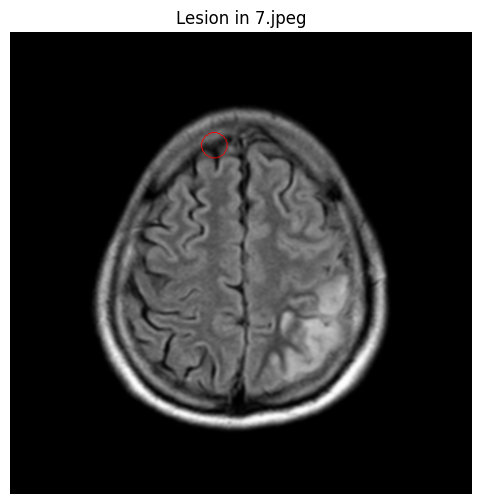


Processing 8.jpg ...
❗ Lesion detected in 8.jpg


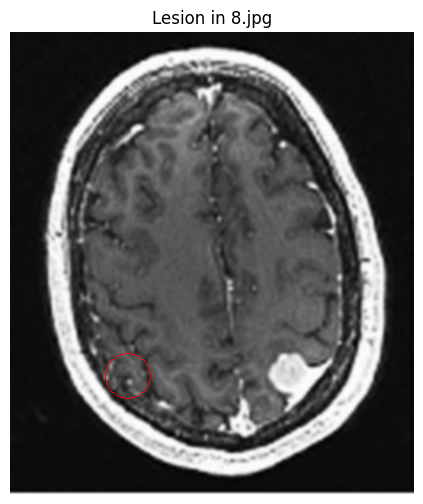

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio
import scipy.ndimage
import os
from skimage.measure import label, regionprops
from skimage.draw import circle_perimeter

def load_and_preprocess_image(path):
    img = iio.imread(path)
    if img.ndim == 3:
        img = np.mean(img, axis=2)
    img = img.astype(np.float32)
    img = scipy.ndimage.gaussian_filter(img, sigma=1)
    img = (img - np.min(img)) / (np.max(img) - np.min(img)) * 255
    return img

def split_hemispheres(img):
    mid = img.shape[1] // 2
    left = img[:, :mid]
    right = np.fliplr(img[:, mid:])
    return left, right

def detect_lesion_mask(left, right, sigma=2, threshold_factor=1.0):
    diff = np.abs(left - right)
    diff_smooth = scipy.ndimage.gaussian_filter(diff, sigma=sigma)
    threshold = np.mean(diff_smooth) + threshold_factor * np.std(diff_smooth)
    mask = diff_smooth > threshold
    mask = scipy.ndimage.binary_opening(mask, structure=np.ones((3, 3)))
    mask = scipy.ndimage.binary_closing(mask, structure=np.ones((3, 3)))
    return mask.astype(np.uint8)

def find_most_probable_lesion_circle(mask, min_area=400, max_area=3000):
    labeled = label(mask)
    regions = regionprops(labeled)

    filtered_regions = [r for r in regions if min_area < r.area < max_area]

    if not filtered_regions:
        return None

    best_region = max(filtered_regions, key=lambda r: r.area)
    y, x = best_region.centroid
    r = best_region.equivalent_diameter / 2
    return (int(x), int(y), int(r))


def draw_circles_on_image(image, circles, title):
    image = image.copy()
    image_rgb = np.stack([image]*3, axis=-1) / 255.0  # grayscale to RGB

    for x, y, r in circles:
        rr, cc = circle_perimeter(y, x, r, shape=image.shape)
        image_rgb[rr, cc] = [1, 0, 0]  # red circles

    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

image_folder = "."
image_names = [f"{i}.jpeg" for i in range(1, 8)] + ["8.jpg"]

for name in image_names:
    path = os.path.join(image_folder, name)
    print(f"\nProcessing {name} ...")

    image = load_and_preprocess_image(path)
    left, right = split_hemispheres(image)

    lesion_mask = detect_lesion_mask(left, right)

    circle = find_most_probable_lesion_circle(lesion_mask)

    if circle:
      print(f"❗ Lesion detected in {name}")
      draw_circles_on_image(image, [circle], f"Lesion in {name}")
    else:
      print(f"✅ No lesion detected in {name}")
      plt.figure(figsize=(6, 6))
      plt.imshow(image, cmap='gray')
      plt.title(f"{name} (No lesion)")
      plt.axis('off')
      plt.show()